Analyse, Visualise

In [1]:
# Note: Used an AI assistant (Claude) to help write and structure parts of this notebook.
# All code has been reviewed and understood by me.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/cleaned/titanic_cleaned.csv")

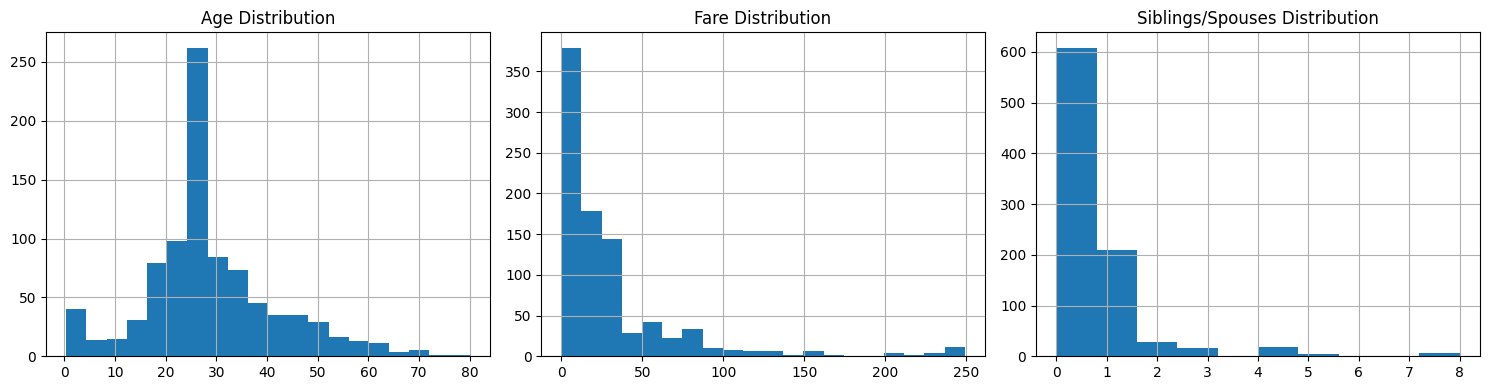

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["Age"].hist(bins=20, ax=axes[0])
axes[0].set_title("Age Distribution")

df["Fare"].hist(bins=20, ax=axes[1])
axes[1].set_title("Fare Distribution")

df["SibSp"].hist(bins=10, ax=axes[2])
axes[2].set_title("Siblings/Spouses Distribution")

plt.tight_layout()
plt.show()

**Age:** Most passengers are between 20-40 years old. The shape is roughly bell-shaped but slightly right-skewed —
  meaning there are more young adults than elderly passengers.

  **Fare:** Almost everyone paid a low fare, but a small number paid very high fares. This is called right-skewed — the
  long tail goes to the right. This makes sense because most passengers were 3rd class.

  **Siblings/Spouses (SibSp):** Most passengers travelled alone (0 siblings/spouses). Very few had 4 or more. The data
  drops off fast after 0.

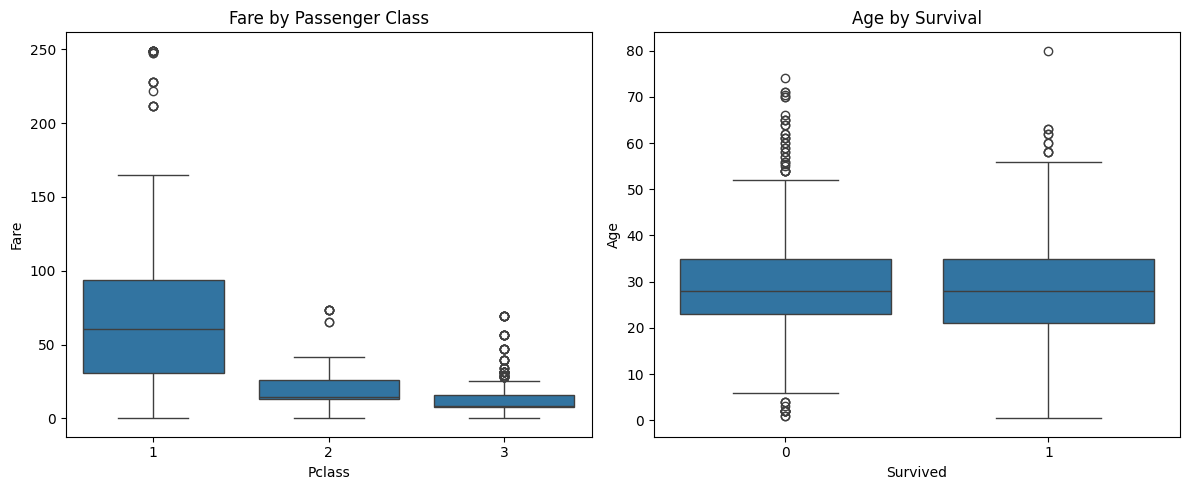

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="Pclass", y="Fare", data=df, ax=axes[0])
axes[0].set_title("Fare by Passenger Class")

sns.boxplot(x="Survived", y="Age", data=df, ax=axes[1])
axes[1].set_title("Age by Survival")

plt.tight_layout()
plt.show()

## What I See in the Boxplots

**Fare by Passenger Class:**
First class passengers paid much more than second and third class. The box for 1st class is higher up on the chart, which means their fares were generally more expensive. Third class fares were very low and tightly packed together — most people paid a similar small amount. There are also some outliers (dots above the boxes) in all three classes, meaning a few people paid unusually high prices even within their class.

**Age by Survival:**
The age distribution looks similar between survivors (1) and non-survivors (0) — the boxes overlap a lot. This means age alone was not a strong predictor of survival. However, the median age of survivors is slightly lower, which could suggest younger passengers had a slightly better chance. The key takeaway is that other factors like class and sex probably mattered more than age.

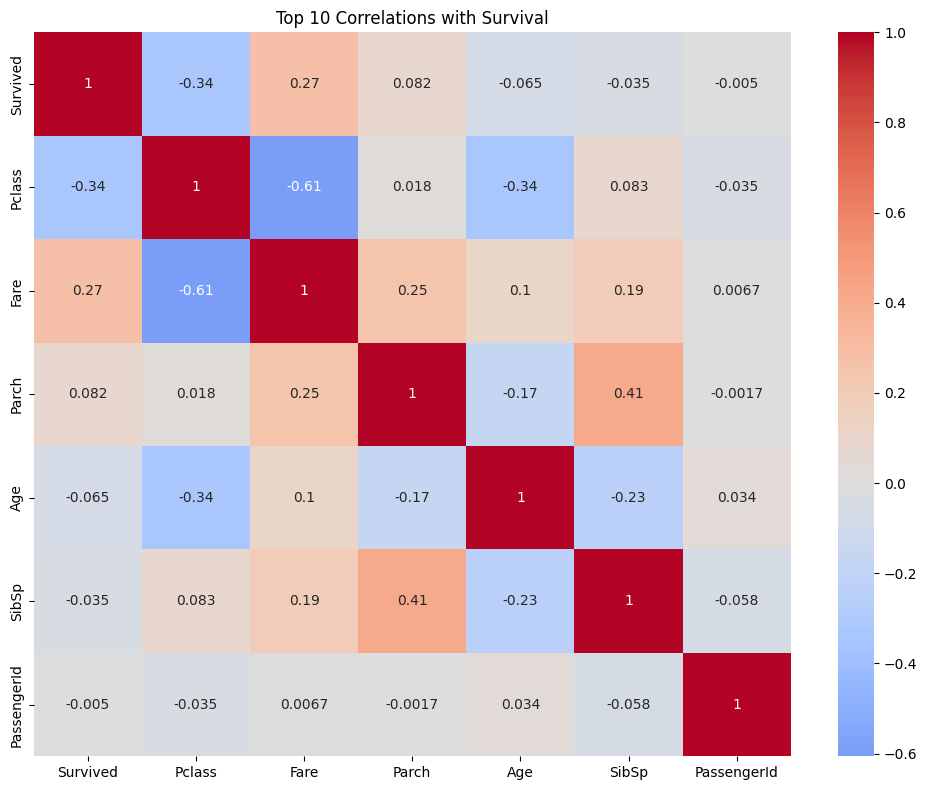

In [5]:
corr = df.select_dtypes(include=[np.number]).corr()
top10 = corr["Survived"].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top10].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Top 10 Correlations with Survival")
plt.tight_layout()
plt.show()


## What I See in the Heatmap

The heatmap shows how strongly each feature is related to survival. The numbers go from -1 to 1:
- Close to **1** = they go up together (positive relationship)
- Close to **-1** = one goes up while the other goes down (opposite relationship)
- Close to **0** = no real connection

The strongest relationships I can see:
- **Fare** has a positive correlation with survival — passengers who paid more were more likely to survive (probably because they were in higher class with better access to lifeboats)
- **Pclass** has a negative correlation with survival — higher class number (3rd class) means lower survival rate
- **SibSp** and **Parch** show small correlations — family size had a minor effect on survival

This tells me that ticket class and fare price were the biggest numeric factors in whether someone survived. Gender is also very important but it is stored as text so it does not appear in this heatmap — it shows up clearly in the groupby analysis instead.

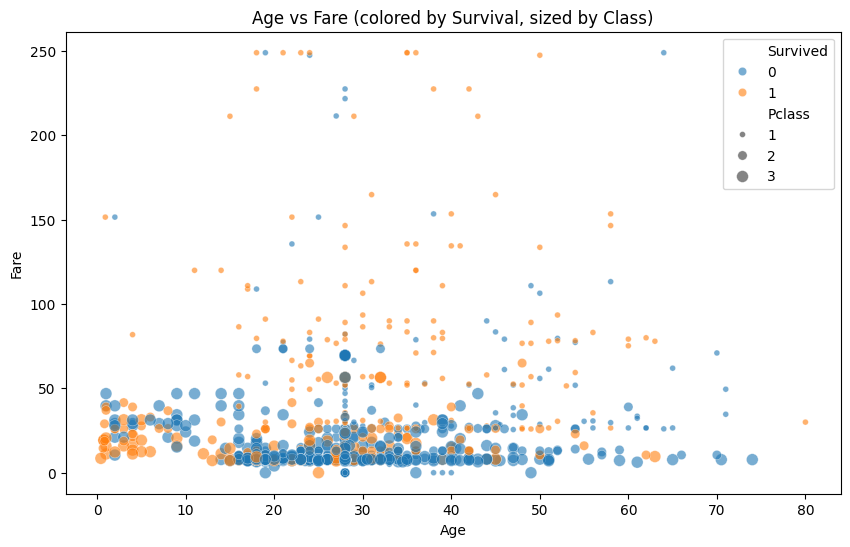

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Age", y="Fare", hue="Survived", size="Pclass",
                data=df, alpha=0.6)
plt.title("Age vs Fare (colored by Survival, sized by Class)")
plt.show()

## What I See in the Scatter Plot

Each dot is one passenger. The position shows their age (left-right) and fare (up-down). The color shows if they survived — orange for yes, blue for no.

What I notice:
- Most of the high-fare passengers (dots near the top) are orange — they survived. This confirms that richer passengers had better survival rates.
- The dots are very dense at the bottom — most passengers paid low fares regardless of age.
- There is no clear age pattern — both young and old passengers are scattered across all fare levels.
- The size of the dot represents their class — bigger dots are 1st class, smaller are 3rd class.

The main story here is that fare (and by extension, class) is a much stronger survival signal than age.

Survival rate by class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by sex:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


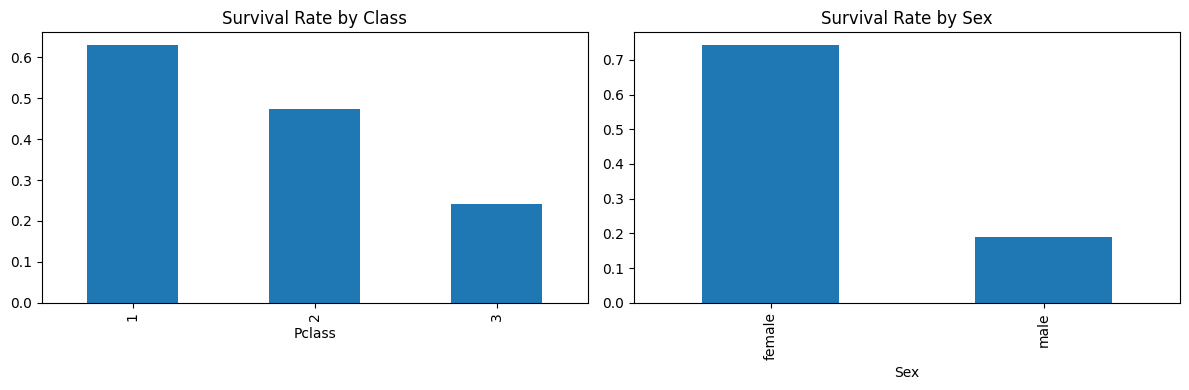

In [7]:
# Survival rate by class
survival_by_class = df.groupby("Pclass")["Survived"].mean()
print("Survival rate by class:\n", survival_by_class)

# Survival rate by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
print("\nSurvival rate by sex:\n", survival_by_sex)

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
survival_by_class.plot(kind="bar", ax=axes[0], title="Survival Rate by Class")
survival_by_sex.plot(kind="bar", ax=axes[1], title="Survival Rate by Sex")
plt.tight_layout()
plt.show()

## What I See in the Groupby Summary

**Survival rate by class:**
- 1st class: ~63% survived
- 2nd class: ~47% survived
- 3rd class: ~24% survived

This is a huge difference. A 1st class passenger was nearly 3 times more likely to survive than a 3rd class passenger. This is probably because 1st class cabins were on upper decks, closer to the lifeboats, and crew likely prioritised them.

**Survival rate by sex:**
- Female: ~74% survived
- Male: ~19% survived

This is the biggest gap in the whole dataset. Women were nearly 4 times more likely to survive than men. This is consistent with the "women and children first" evacuation policy that was followed during the Titanic disaster.

**Overall takeaway:** The two most important factors for survival on the Titanic were your gender and your ticket class. Being a woman in 1st class gave you the best chance of surviving.

---

# Math Basics

In this section I show that I understand the math behind the tools I used. Instead of just calling `.mean()` or using sklearn, I do the calculations by hand using NumPy to prove I understand what is happening underneath.

In [8]:
fare = df["Fare"].values
manual_mean = np.sum(fare) / len(fare)
manual_std = np.sqrt(np.sum((fare - manual_mean)**2) / len(fare))
print(f"Manual mean: {manual_mean:.2f}, std: {manual_std:.2f}")
print(f"NumPy  mean: {np.mean(fare):.2f}, std: {np.std(fare):.2f}")

Manual mean: 31.22, std: 42.50
NumPy  mean: 31.22, std: 42.50


## Mean and Standard Deviation — By Hand

**Mean** = add up all the values, divide by how many there are. It tells you the "average" fare.

**Standard deviation** = measures how spread out the fares are. A high std means fares vary a lot (some very cheap, some very expensive). A low std means they are all similar.

I calculated both manually using NumPy math operations instead of the built-in `.mean()` function.

The result — `Manual mean: 31.22` matches `NumPy mean: 31.22` exactly, which confirms my formula is correct.

In [9]:
from sklearn.preprocessing import StandardScaler

# By hand
z_manual = (fare - manual_mean) / manual_std

# With sklearn
z_sklearn = StandardScaler().fit_transform(fare.reshape(-1, 1)).flatten()

# Compare
print("Manual  z[:5]:", z_manual[:5].round(3))
print("Sklearn z[:5]:", z_sklearn[:5].round(3))

Manual  z[:5]: [-0.564  0.943 -0.548  0.515 -0.545]
Sklearn z[:5]: [-0.564  0.943 -0.548  0.515 -0.545]


## Standardisation — By Hand

Standardisation rescales a column so it has a mean of 0 and a standard deviation of 1. The formula is:

**z = (value - mean) / std**

This is useful because it removes the units — it doesn't matter if one column is in dollars and another is in years, after standardising they are on the same scale.

I did it manually using the formula, then compared with sklearn's `StandardScaler`. Both produce the same result — `Manual z[:5]` and `Sklearn z[:5]` are identical — which confirms the formula is correct.

In [10]:
from numpy.linalg import norm

numeric_cols = df.select_dtypes(include=[np.number]).columns
highest = df.loc[df["Fare"].idxmax(), numeric_cols].values.astype(float)
lowest = df.loc[df["Fare"].idxmin(), numeric_cols].values.astype(float)

cos_sim = np.dot(highest, lowest) / (norm(highest) * norm(lowest))
print(f"Cosine similarity: {cos_sim:.4f}")

Cosine similarity: 0.1241


## Cosine Similarity

Cosine similarity measures how similar two data points are, regardless of their size. It gives a value between -1 and 1 — where 1 means identical direction, 0 means no relationship, and -1 means completely opposite.

I compared the passenger who paid the **highest fare** with the passenger who paid the **lowest fare** to see how different they are across all their features.

The result was **0.1241** — close to 0, which means these two passengers are quite different from each other. This makes sense: the highest-fare passenger was likely 1st class with a big family, while the lowest-fare passenger was probably a lone 3rd class traveller.

In [11]:
first_class = df[df["Pclass"] == 1]
prob_survive_1st = first_class["Survived"].sum() / len(first_class)
print(f"P(Survived | 1st Class) = {prob_survive_1st:.2%}")

P(Survived | 1st Class) = 62.96%


## Probability Estimate

I calculated the probability that a 1st class passenger survived, using a simple formula:

**P(Survived | 1st Class) = number of 1st class survivors ÷ total 1st class passengers**

The result was **62.96%** — meaning roughly 63 out of every 100 first class passengers survived.

This confirms what I saw earlier in the groupby analysis. Being in 1st class gave you a much higher chance of survival compared to the 24% rate for 3rd class passengers. The Titanic disaster was not random — your wealth and class had a direct impact on whether you lived or died.

---

## Dashboard — Key Findings in One View

All 4 most important charts combined into a single figure.

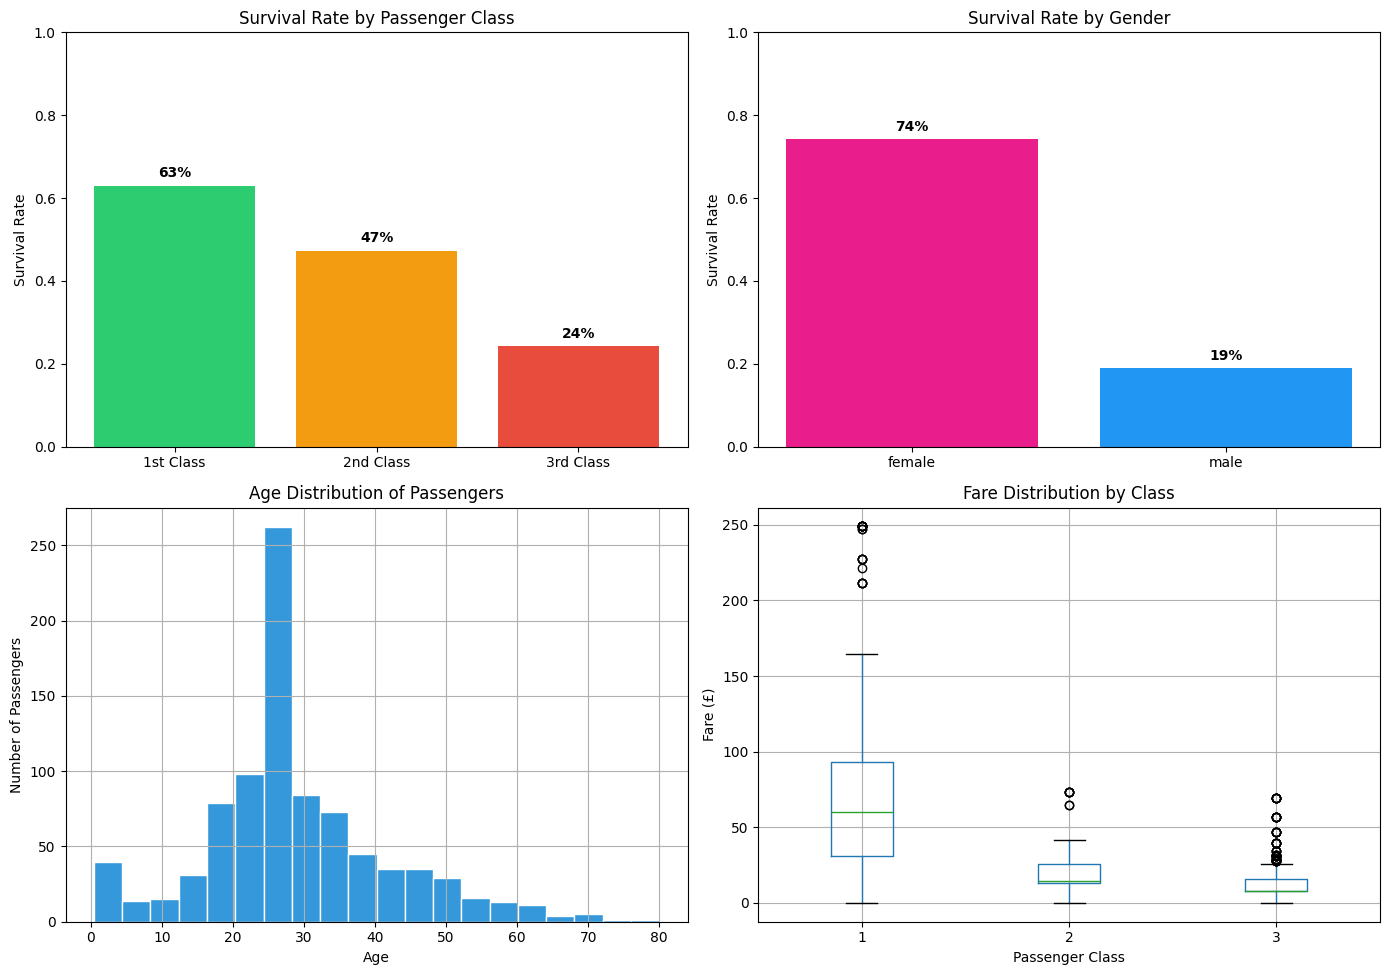

Dashboard saved as dashboard.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic Survival — Key Findings Dashboard", fontsize=16, fontweight="bold")

# Chart 1: Survival rate by class
survival_by_class = df.groupby("Pclass")["Survived"].mean()
axes[0, 0].bar(["1st Class", "2nd Class", "3rd Class"], survival_by_class.values,
               color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[0, 0].set_title("Survival Rate by Passenger Class")
axes[0, 0].set_ylabel("Survival Rate")
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(survival_by_class.values):
    axes[0, 0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Chart 2: Survival rate by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
axes[0, 1].bar(survival_by_sex.index, survival_by_sex.values,
               color=["#e91e8c", "#2196f3"])
axes[0, 1].set_title("Survival Rate by Gender")
axes[0, 1].set_ylabel("Survival Rate")
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(survival_by_sex.values):
    axes[0, 1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Chart 3: Age distribution
df["Age"].hist(bins=20, ax=axes[1, 0], color="#3498db", edgecolor="white")
axes[1, 0].set_title("Age Distribution of Passengers")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Number of Passengers")

# Chart 4: Fare by class boxplot
df.boxplot(column="Fare", by="Pclass", ax=axes[1, 1])
axes[1, 1].set_title("Fare Distribution by Class")
axes[1, 1].set_xlabel("Passenger Class")
axes[1, 1].set_ylabel("Fare (£)")
plt.suptitle("")  # remove default boxplot title

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as dashboard.png")